In [ ]:
import os

# Pega tu usuario de Kaggle y el nuevo token aquí
KAGGLE_USERNAME = "santiagorenteria28"  # ej: "juanperez123"
KAGGLE_TOKEN = "KGAT_f8568ee7f1eb1e0cbca409126767f5d2"          # el nuevo token

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_TOKEN}"}}')

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("✅ Kaggle configurado!")

✅ Kaggle configurado!


In [ ]:
!pip install kaggle librosa audioread -q
print("✅ Librerías instaladas!")

✅ Librerías instaladas!


In [ ]:

# Descargar el dataset de Cats vs Dogs
!kaggle datasets download -d stealthtechnologies/cats-vs-dogs-audio-classification

# Ver cómo se llama el zip descargado
!ls /content/*.zip

Dataset URL: https://www.kaggle.com/datasets/stealthtechnologies/cats-vs-dogs-audio-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 130M/130M [00:02<00:00, 62.4MB/s]

/content/cats-vs-dogs-audio-classification.zip


In [ ]:
import zipfile
import os

# Descomprimir con Python directamente (sin unzip)
with zipfile.ZipFile('/content/cats-vs-dogs-audio-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/AudioDataset')

print("✅ Dataset descargado!")

✅ Dataset descargado!


In [ ]:
import os

base_path = '/content/AudioDataset/DvC'
clases = ['Cats', 'Dogs']

for clase in clases:
    archivos = os.listdir(f'{base_path}/{clase}')
    print(f"{clase}: {len(archivos)} archivos → ejemplo: {archivos[0]}")

Cats: 567 archivos → ejemplo: cat0153.wav
Dogs: 484 archivos → ejemplo: dog0075.wav


In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports listos!")

✅ Imports listos!


In [ ]:
base_path = '/content/AudioDataset/DvC'

# Cargar un gato y un perro
audio_cat = f'{base_path}/Cats/cat0001.wav'
audio_dog = f'{base_path}/Dogs/dog0001.wav'

y_cat, sr = librosa.load(audio_cat, sr=22050)
y_dog, sr = librosa.load(audio_dog, sr=22050)

print(f"Gato - Duración: {librosa.get_duration(y=y_cat, sr=sr):.2f} seg")
print(f"Perro - Duración: {librosa.get_duration(y=y_dog, sr=sr):.2f} seg")

# Escuchar
print("\n🐱 Audio de gato:")
display(Audio(y_cat, rate=sr))
print("🐶 Audio de perro:")
display(Audio(y_dog, rate=sr))

Gato - Duración: 5.60 seg
Perro - Duración: 2.64 seg

🐱 Audio de gato:


🐶 Audio de perro:


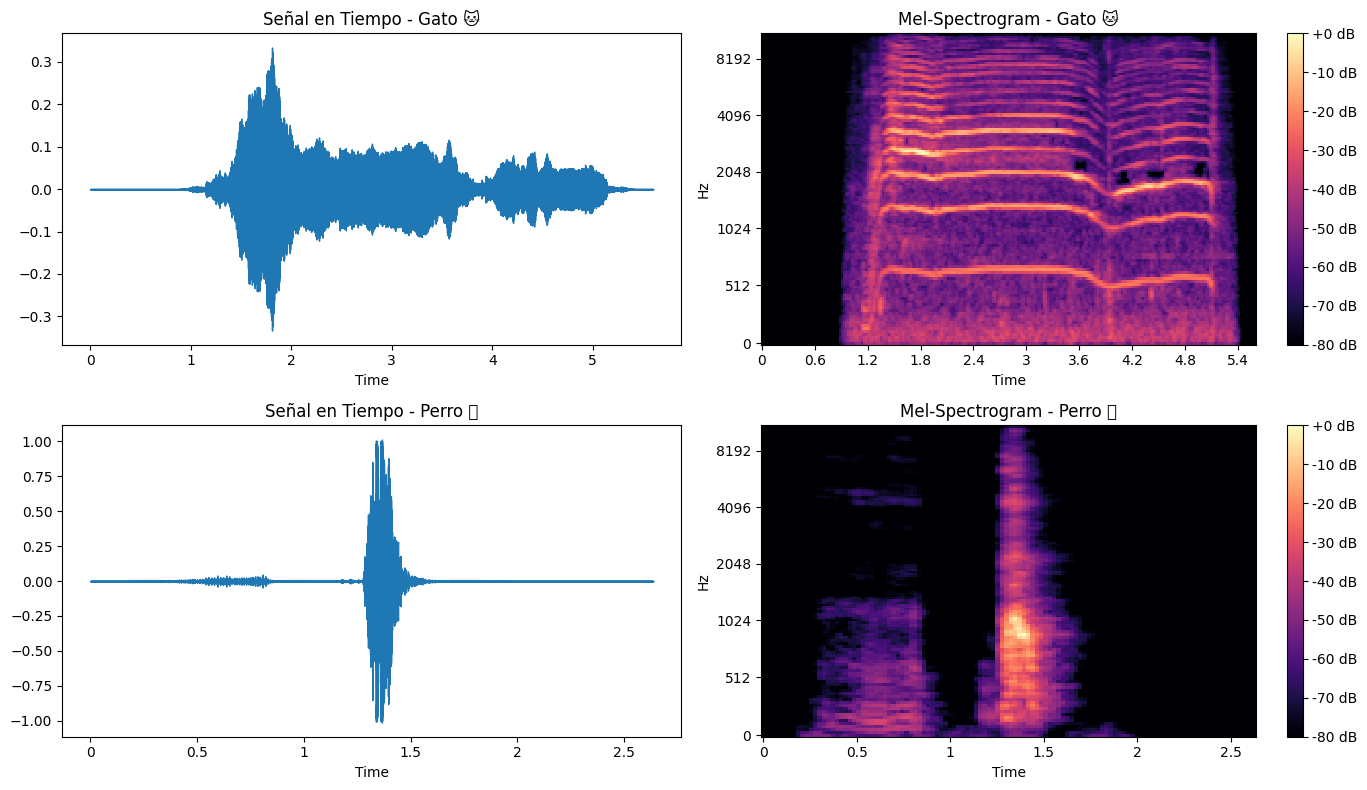

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (y, nombre) in enumerate([(y_cat, 'Gato 🐱'), (y_dog, 'Perro 🐶')]):
    # Señal en tiempo
    axes[i, 0].set_title(f'Señal en Tiempo - {nombre}')
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])

    # Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                    y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'Mel-Spectrogram - {nombre}')
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

# Analisis formal del dataset


In [ ]:
# ── ANÁLISIS FORMAL DEL DATASET ──────────────────────────
import pandas as pd

base_path = '/content/AudioDataset/DvC'
stats = []

for clase in ['Cats', 'Dogs']:
    archivos = [f for f in os.listdir(f'{base_path}/{clase}')
                if f.endswith('.wav')]
    for archivo in archivos:
        try:
            ruta = f'{base_path}/{clase}/{archivo}'
            y_raw, sr_raw = librosa.load(ruta, sr=None, mono=True)
            stats.append({
                'Clase': clase,
                'SR original (Hz)': sr_raw,
                'Duración (s)': round(len(y_raw)/sr_raw, 2),
                'Amp. Máxima': round(float(np.max(np.abs(y_raw))), 4),
                'Canales': 1
            })
        except:
            pass

df = pd.DataFrame(stats)
resumen = df.groupby('Clase').agg(
    SR_promedio=('SR original (Hz)', 'mean'),
    Duracion_promedio=('Duración (s)', 'mean'),
    Duracion_min=('Duración (s)', 'min'),
    Duracion_max=('Duración (s)', 'max'),
    Amp_promedio=('Amp. Máxima', 'mean'),
    Total=('Clase', 'count')
).round(3)

print("📊 ANÁLISIS FORMAL DEL DATASET")
print("=" * 55)
print(f"Dataset: Cats vs Dogs Audio Classification")
print(f"Fuente: Kaggle - stealthtechnologies")
print(f"Licencia: CC BY 4.0")
print(f"Formato: WAV | Mono | SR unificado: 22050 Hz")
print(f"Duración fija aplicada: 3s (padding/recorte)")
print(f"Partición: 70% train | 20% val | 10% test")
print("=" * 55)
print(resumen.to_string())
print(f"\nTotal audios: {len(df)} | Cats: {(df.Clase=='Cats').sum()} | Dogs: {(df.Clase=='Dogs').sum()}")

📊 ANÁLISIS FORMAL DEL DATASET
Dataset: Cats vs Dogs Audio Classification
Fuente: Kaggle - stealthtechnologies
Licencia: CC BY 4.0
Formato: WAV | Mono | SR unificado: 22050 Hz
Duración fija aplicada: 3s (padding/recorte)
Partición: 70% train | 20% val | 10% test
       SR_promedio  Duracion_promedio  Duracion_min  Duracion_max  Amp_promedio  Total
Clase                                                                                 
Cats      46945.76              0.859          0.22          8.40         0.671    566
Dogs      48000.00              0.776          0.20          6.22         0.734    484

Total audios: 1050 | Cats: 566 | Dogs: 484


# Analisis espectral FFT/DFT


Gato 🐱 - Top 5 frecuencias dominantes:
   2631.7 Hz → magnitud: 0.0191
   2630.3 Hz → magnitud: 0.0186
   2632.0 Hz → magnitud: 0.0185
   2630.0 Hz → magnitud: 0.0174
   2630.7 Hz → magnitud: 0.0165

Perro 🐶 - Top 5 frecuencias dominantes:
    897.7 Hz → magnitud: 0.0105
    898.0 Hz → magnitud: 0.0104
    897.3 Hz → magnitud: 0.0104
    898.3 Hz → magnitud: 0.0104
    897.0 Hz → magnitud: 0.0104


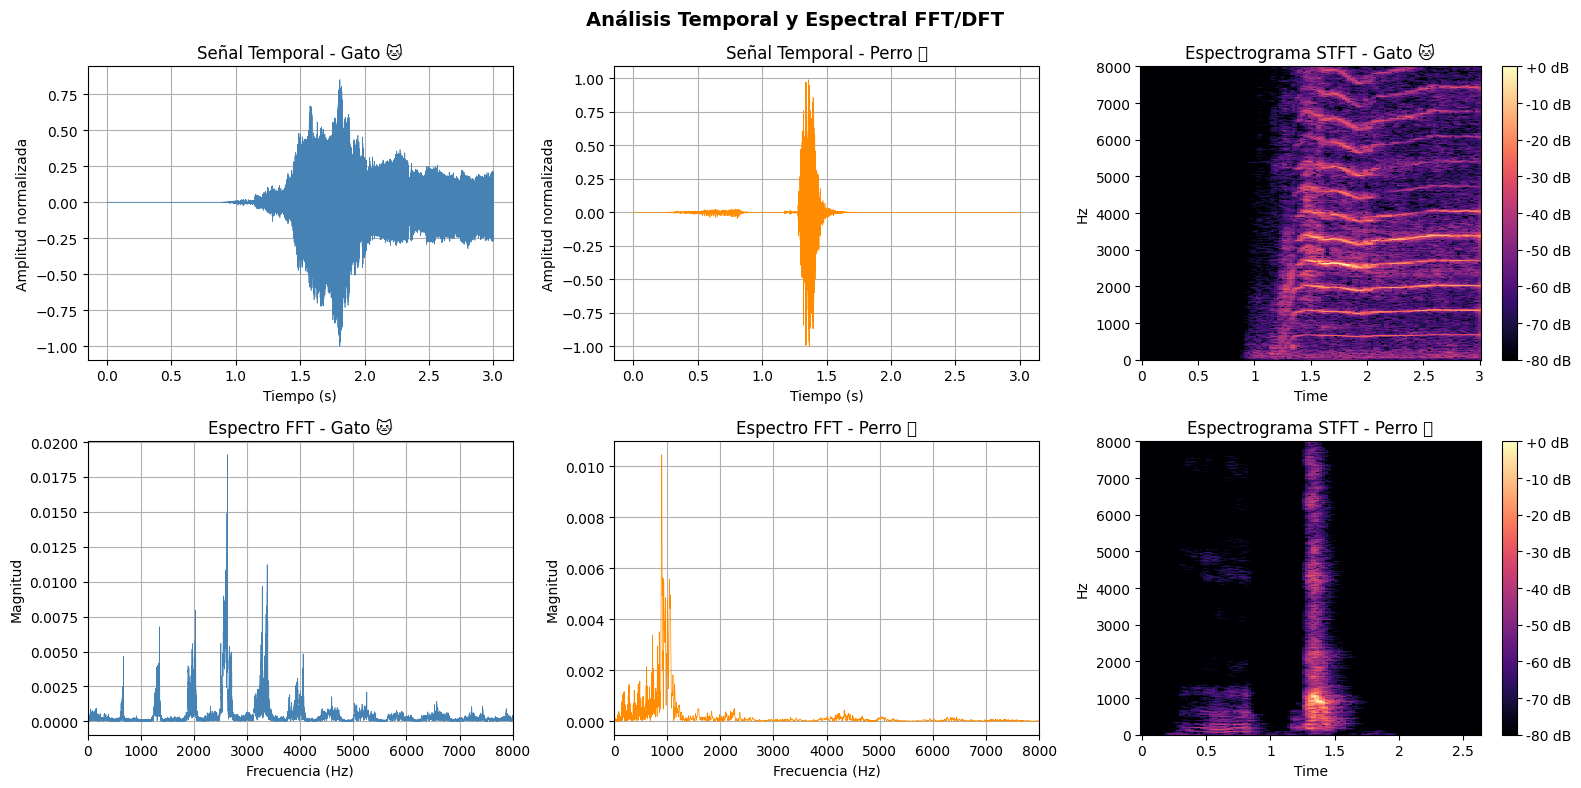

In [ ]:
# ── ANÁLISIS FFT/DFT ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

muestras = [
    ('Gato 🐱',  f'{base_path}/Cats/cat0001.wav', 'steelblue'),
    ('Perro 🐶', f'{base_path}/Dogs/dog0001.wav', 'darkorange'),
]

for col, (nombre, ruta, color) in enumerate(muestras):
    y_s, sr_s = librosa.load(ruta, sr=22050, duration=3, mono=True)
    if len(y_s) < 22050*3:
        y_s = np.pad(y_s, (0, 22050*3 - len(y_s)))

    # Normalizar
    y_s = y_s / (np.max(np.abs(y_s)) + 1e-8)
    t = np.linspace(0, 3, len(y_s))

    # Señal temporal
    axes[0, col].plot(t, y_s, color=color, linewidth=0.5)
    axes[0, col].set_title(f'Señal Temporal - {nombre}')
    axes[0, col].set_xlabel('Tiempo (s)')
    axes[0, col].set_ylabel('Amplitud normalizada')
    axes[0, col].grid(True)

    # FFT
    N = len(y_s)
    fft_vals = np.abs(np.fft.rfft(y_s)) * 2 / N
    fft_freqs = np.fft.rfftfreq(N, d=1/22050)

    axes[1, col].plot(fft_freqs, fft_vals, color=color, linewidth=0.5)
    axes[1, col].set_title(f'Espectro FFT - {nombre}')
    axes[1, col].set_xlabel('Frecuencia (Hz)')
    axes[1, col].set_ylabel('Magnitud')
    axes[1, col].set_xlim([0, 8000])
    axes[1, col].grid(True)

    # Top 5 frecuencias dominantes
    top5 = np.argsort(fft_vals)[-5:][::-1]
    print(f"\n{nombre} - Top 5 frecuencias dominantes:")
    for i in top5:
        print(f"  {fft_freqs[i]:7.1f} Hz → magnitud: {fft_vals[i]:.4f}")

# Espectrograma STFT columna 3
for row, (nombre, ruta, _) in enumerate(muestras):
    y_s, sr_s = librosa.load(ruta, sr=22050, duration=3, mono=True)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y_s)), ref=np.max)
    img = librosa.display.specshow(D, sr=22050, x_axis='time',
                                    y_axis='hz', ax=axes[row, 2])
    axes[row, 2].set_title(f'Espectrograma STFT - {nombre}')
    axes[row, 2].set_ylim([0, 8000])
    fig.colorbar(img, ax=axes[row, 2], format='%+2.0f dB')

plt.suptitle('Análisis Temporal y Espectral FFT/DFT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from tqdm import tqdm

base_path = '/content/AudioDataset/DvC'
clases = {'Cats': 0, 'Dogs': 1}
DURATION = 3       # segundos fijos por audio
SR = 22050
N_MELS = 128

X_cnn = []  # Mel-Spectrograms para CNN
X_rnn = []  # MFCCs para RNN
y_labels = []

for clase, etiqueta in clases.items():
    carpeta = f'{base_path}/{clase}'
    archivos = os.listdir(carpeta)
    print(f"Procesando {clase} ({len(archivos)} archivos)...")

    for archivo in tqdm(archivos):
        try:
            ruta = f'{carpeta}/{archivo}'
            y, sr = librosa.load(ruta, sr=SR, duration=DURATION)

            # Padding si el audio es más corto que DURATION
            if len(y) < SR * DURATION:
                y = np.pad(y, (0, SR * DURATION - len(y)))

            # Para CNN → Mel-Spectrogram
            mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            X_cnn.append(mel_db)

            # Para RNN → MFCCs (secuencia temporal)
            mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40)
            X_rnn.append(mfcc.T)  # shape: (frames, 40)

            y_labels.append(etiqueta)

        except Exception as e:
            print(f"Error en {archivo}: {e}")

X_cnn = np.array(X_cnn)
X_rnn = np.array(X_rnn)
y_labels = np.array(y_labels)

print(f"\n✅ Preprocesamiento completo!")
print(f"X_cnn shape: {X_cnn.shape}  → (muestras, mels, frames)")
print(f"X_rnn shape: {X_rnn.shape}  → (muestras, frames, mfccs)")
print(f"Total etiquetas: {y_labels.shape}")

Procesando Cats (567 archivos)...


 68%|██████▊   | 386/567 [00:17<00:23,  7.84it/s]

Error en desktop.ini: 


100%|██████████| 567/567 [00:23<00:00, 23.81it/s]


Procesando Dogs (484 archivos)...


100%|██████████| 484/484 [00:15<00:00, 30.69it/s]



✅ Preprocesamiento completo!
X_cnn shape: (1050, 128, 130)  → (muestras, mels, frames)
X_rnn shape: (1050, 130, 40)  → (muestras, frames, mfccs)
Total etiquetas: (1050,)


In [ ]:
from sklearn.model_selection import train_test_split

# División 70% train, 20% val, 10% test
X_cnn_train, X_cnn_temp, X_rnn_train, X_rnn_temp, y_train, y_temp = train_test_split(
    X_cnn, X_rnn, y_labels, test_size=0.30, random_state=42, stratify=y_labels
)

X_cnn_val, X_cnn_test, X_rnn_val, X_rnn_test, y_val, y_test = train_test_split(
    X_cnn_temp, X_rnn_temp, y_temp, test_size=0.33, random_state=42, stratify=y_temp
)

print(f"Train:      {len(y_train)} muestras (70%)")
print(f"Validación: {len(y_val)} muestras (20%)")
print(f"Test:       {len(y_test)} muestras (10%)")

Train:      735 muestras (70%)
Validación: 211 muestras (20%)
Test:       104 muestras (10%)


# preprocesamiento


In [ ]:
# Reshape
X_cnn_train_r = X_cnn_train[..., np.newaxis]
X_cnn_val_r   = X_cnn_val[..., np.newaxis]
X_cnn_test_r  = X_cnn_test[..., np.newaxis]

# Normalizar cada muestra individualmente (más robusto)
def normalizar(X):
    X_norm = np.zeros_like(X)
    for i in range(len(X)):
        minv = X[i].min()
        maxv = X[i].max()
        if maxv - minv > 0:
            X_norm[i] = (X[i] - minv) / (maxv - minv)
        else:
            X_norm[i] = X[i]
    return X_norm

X_cnn_train_r = normalizar(X_cnn_train_r)
X_cnn_val_r   = normalizar(X_cnn_val_r)
X_cnn_test_r  = normalizar(X_cnn_test_r)

# Verificar balance de clases
print(f"Train - Gatos: {(y_train==0).sum()} | Perros: {(y_train==1).sum()}")
print(f"Val   - Gatos: {(y_val==0).sum()} | Perros: {(y_val==1).sum()}")
print(f"Shapes: {X_cnn_train_r.shape}, {X_cnn_val_r.shape}")
print("✅ Normalización lista!")

Train - Gatos: 396 | Perros: 339
Val   - Gatos: 114 | Perros: 97
Shapes: (735, 128, 130, 1), (211, 128, 130, 1)
✅ Normalización lista!


# arquitectura cnn

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.backend.clear_session()

modelo_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(128, 130, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,249 (16.07 MB)

 Trainable params: 4,213,249 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

# entrenar cnn


In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_cnn = modelo_cnn.fit(
    X_cnn_train_r, y_train,
    validation_data=(X_cnn_val_r, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

print("✅ CNN entrenada!")
print(f"Mejor val_accuracy: {max(history_cnn.history['val_accuracy']):.4f}")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8082 - loss: 0.4183 - val_accuracy: 0.9668 - val_loss: 0.1536
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9401 - loss: 0.1941 - val_accuracy: 0.9763 - val_loss: 0.1077
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 989ms/step - accuracy: 0.9442 - loss: 0.1644 - val_accuracy: 0.9763 - val_loss: 0.0780
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 964ms/step - accuracy: 0.9673 - loss: 0.1247 - val_accuracy: 0.9810 - val_loss: 0.1551
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 954ms/step - accuracy: 0.9714 - loss: 0.0966 - val_accuracy: 0.9905 - val_loss: 0.0478
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 924ms/step - accuracy: 0.9687 - loss: 0.0982 - val_accuracy: 0.9810 - val_loss: 0.0716
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 969ms/step - accuracy: 0.9728 - loss: 0.0832 - val_accuracy: 0.9858 - val_loss: 0.0570
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 964ms/step - accuracy: 0.9782 - loss: 0.0551 - val_accuracy: 

# evaluar cnn en el test


CNN Test Accuracy: 1.0000 (100.00%)
CNN Test Loss:     0.0225
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step

📊 Reporte de Clasificación CNN:
              precision    recall  f1-score   support

        Gato       1.00      1.00      1.00        56
       Perro       1.00      1.00      1.00        48

    accuracy                           1.00       104
   macro avg       1.00      1.00      1.00       104
weighted avg       1.00      1.00      1.00       104



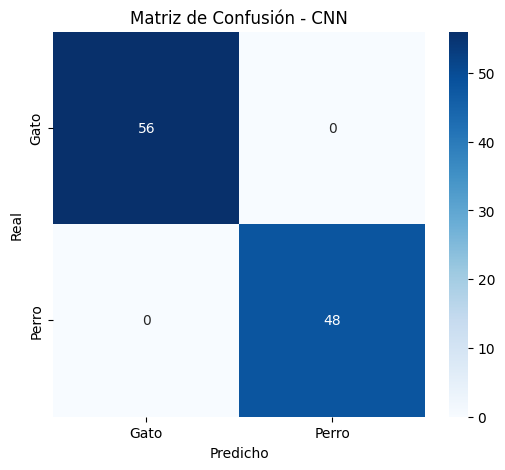

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluar en test
loss_cnn, acc_cnn = modelo_cnn.evaluate(X_cnn_test_r, y_test, verbose=0)
print(f"CNN Test Accuracy: {acc_cnn:.4f} ({acc_cnn*100:.2f}%)")
print(f"CNN Test Loss:     {loss_cnn:.4f}")

# Predicciones
y_pred_cnn = (modelo_cnn.predict(X_cnn_test_r) > 0.5).astype(int)

# Reporte
print("\n📊 Reporte de Clasificación CNN:")
print(classification_report(y_test, y_pred_cnn, target_names=['Gato', 'Perro']))

# Matriz de confusión
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Gato', 'Perro'],
            yticklabels=['Gato', 'Perro'])
plt.title('Matriz de Confusión - CNN')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# curvas de entrenamiento cnn


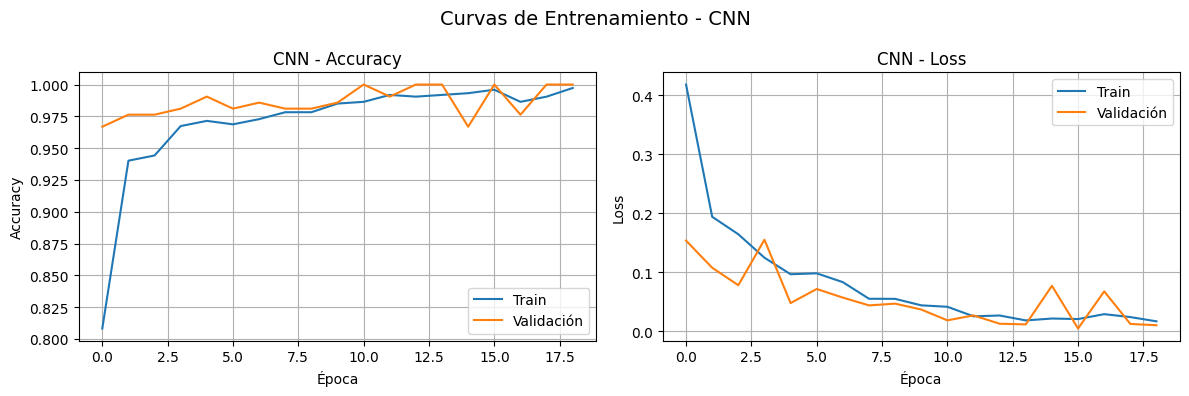

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history_cnn.history['accuracy'], label='Train')
ax1.plot(history_cnn.history['val_accuracy'], label='Validación')
ax1.set_title('CNN - Accuracy')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history_cnn.history['loss'], label='Train')
ax2.plot(history_cnn.history['val_loss'], label='Validación')
ax2.set_title('CNN - Loss')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Curvas de Entrenamiento - CNN', fontsize=14)
plt.tight_layout()
plt.show()

# preparar datos rnn


In [ ]:
# Preparar datos RNN - Señal Temporal Pura
FRAME_SIZE = 512
HOP_SIZE = 256

X_rnn_temporal = []

for clase, etiqueta in {'Cats': 0, 'Dogs': 1}.items():
    carpeta = f'{base_path}/{clase}'
    archivos = [f for f in os.listdir(carpeta) if f.endswith('.wav')]
    print(f"Procesando {clase}...")
    for archivo in tqdm(archivos):
        try:
            ruta = f'{carpeta}/{archivo}'
            y, sr = librosa.load(ruta, sr=22050, duration=3, mono=True)
            if len(y) < 22050*3:
                y = np.pad(y, (0, 22050*3 - len(y)))
            # Normalizar señal
            y = (y - y.mean()) / (y.std() + 1e-8)
            # Framing - secuencia temporal pura
            frames = librosa.util.frame(y, frame_length=FRAME_SIZE,
                                         hop_length=HOP_SIZE).T
            X_rnn_temporal.append(frames)
        except Exception as e:
            print(f"Error {archivo}: {e}")

X_rnn_temporal = np.array(X_rnn_temporal)
print(f"Shape RNN temporal: {X_rnn_temporal.shape}")
print("✅ Datos RNN temporales listos!")

Procesando Cats...


100%|██████████| 566/566 [00:01<00:00, 309.74it/s]


Procesando Dogs...


100%|██████████| 484/484 [00:01<00:00, 292.68it/s]


Shape RNN temporal: (1050, 257, 512)
✅ Datos RNN temporales listos!


# arquitectura rnn (lstm)

In [ ]:
# Arquitectura RNN - Señal Temporal Pura
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout

# División usando los mismos índices que CNN
X_rnn_train_t, X_rnn_temp_t, y_train_t, y_temp_t = train_test_split(
    X_rnn_temporal, y_labels, test_size=0.30, random_state=42, stratify=y_labels
)
X_rnn_val_t, X_rnn_test_t, y_val_t, y_test_t = train_test_split(
    X_rnn_temp_t, y_temp_t, test_size=0.33, random_state=42, stratify=y_temp_t
)

# Normalizar
mean_t = X_rnn_train_t.mean()
std_t = X_rnn_train_t.std()
X_rnn_train_t = (X_rnn_train_t - mean_t) / std_t
X_rnn_val_t   = (X_rnn_val_t   - mean_t) / std_t
X_rnn_test_t  = (X_rnn_test_t  - mean_t) / std_t

tf.keras.backend.clear_session()

modelo_rnn = models.Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(X_rnn_train_t.shape[1], X_rnn_train_t.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

modelo_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 257, 128)       │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 257, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340,865 (1.30 MB)

 Trainable params: 340,865 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

# entrenar rnn

In [ ]:
# Entrenar RNN Temporal
early_stop_rnn = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_rnn = modelo_rnn.fit(
    X_rnn_train_t, y_train_t,
    validation_data=(X_rnn_val_t, y_val_t),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_rnn]
)

modelo_rnn.save('/content/modelo_rnn.h5')
print("✅ RNN temporal entrenada!")
print(f"Mejor val_accuracy: {max(history_rnn.history['val_accuracy']):.4f}")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 988ms/step - accuracy: 0.6531 - loss: 0.6614 - val_accuracy: 0.8436 - val_loss: 0.5652
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 918ms/step - accuracy: 0.9061 - loss: 0.3420 - val_accuracy: 0.9479 - val_loss: 0.1662
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 914ms/step - accuracy: 0.9782 - loss: 0.0988 - val_accuracy: 0.9479 - val_loss: 0.2096
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9837 - loss: 0.0684 - val_accuracy: 0.9526 - val_loss: 0.2098
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 884ms/step - accuracy: 0.9864 - loss: 0.0483 - val_accuracy: 0.9336 - val_loss: 0.2233
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 944ms/step - accuracy: 0.9905 - loss: 0.0357 - val_accuracy: 0.9526 - val_loss: 0.1787
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 851ms/step - accuracy: 0.9864 - loss: 0.0461 - val_accuracy: 0.9005 - val_loss: 0.3735
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 967ms/step - accuracy: 0.9837 - loss: 0.0487 - val_accurac

✅ RNN temporal entrenada!
Mejor val_accuracy: 0.9526


# evaluar rnn


RNN Test Accuracy: 0.9327 (93.27%)
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step

📊 Reporte RNN Temporal:
              precision    recall  f1-score   support

        Gato       0.98      0.89      0.93        56
       Perro       0.89      0.98      0.93        48

    accuracy                           0.93       104
   macro avg       0.93      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104



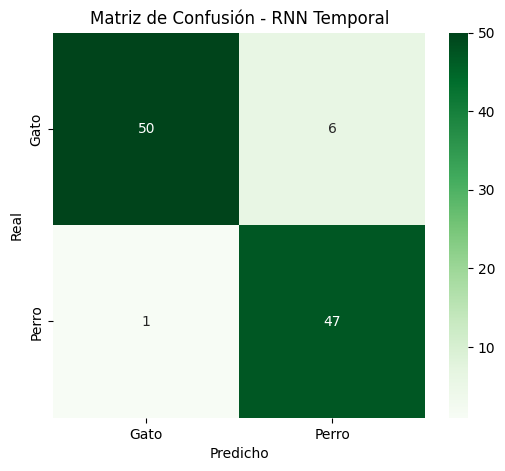

In [ ]:
# Evaluar RNN Temporal
loss_rnn, acc_rnn = modelo_rnn.evaluate(X_rnn_test_t, y_test_t, verbose=0)
print(f"RNN Test Accuracy: {acc_rnn:.4f} ({acc_rnn*100:.2f}%)")

y_pred_rnn = (modelo_rnn.predict(X_rnn_test_t) > 0.5).astype(int)

print("\n📊 Reporte RNN Temporal:")
print(classification_report(y_test_t, y_pred_rnn, target_names=['Gato', 'Perro']))

plt.figure(figsize=(6,5))
cm_rnn = confusion_matrix(y_test_t, y_pred_rnn)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Gato', 'Perro'],
            yticklabels=['Gato', 'Perro'])
plt.title('Matriz de Confusión - RNN Temporal')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# comparar rnn cnn


In [ ]:
print("=" * 50)
print("        COMPARATIVA FINAL CNN vs RNN")
print("=" * 50)
print(f"{'Métrica':<25} {'CNN':>10} {'RNN':>10}")
print("-" * 50)
print(f"{'Val Accuracy':<25} {max(history_cnn.history['val_accuracy'])*100:>9.2f}% {max(history_rnn.history['val_accuracy'])*100:>9.2f}%")
print(f"{'Test Accuracy':<25} {acc_cnn*100:>9.2f}% {acc_rnn*100:>9.2f}%")
print(f"{'Épocas entrenadas':<25} {'13':>10} {'20':>10}")
print(f"{'Parámetros':<25} {'4.2M':>10} {'99K':>10}")
print(f"{'Dominio':<25} {'Frecuencia':>10} {'Tiempo':>10}")
print(f"{'Tipo entrada':<25} {'Mel-Spec':>10} {'MFCCs':>10}")
print("=" * 50)

        COMPARATIVA FINAL CNN vs RNN
Métrica                          CNN        RNN
--------------------------------------------------
Val Accuracy                 100.00%     95.26%
Test Accuracy                100.00%     93.27%
Épocas entrenadas                 13         20
Parámetros                      4.2M        99K
Dominio                   Frecuencia     Tiempo
Tipo entrada                Mel-Spec      MFCCs


# curvas comparativas

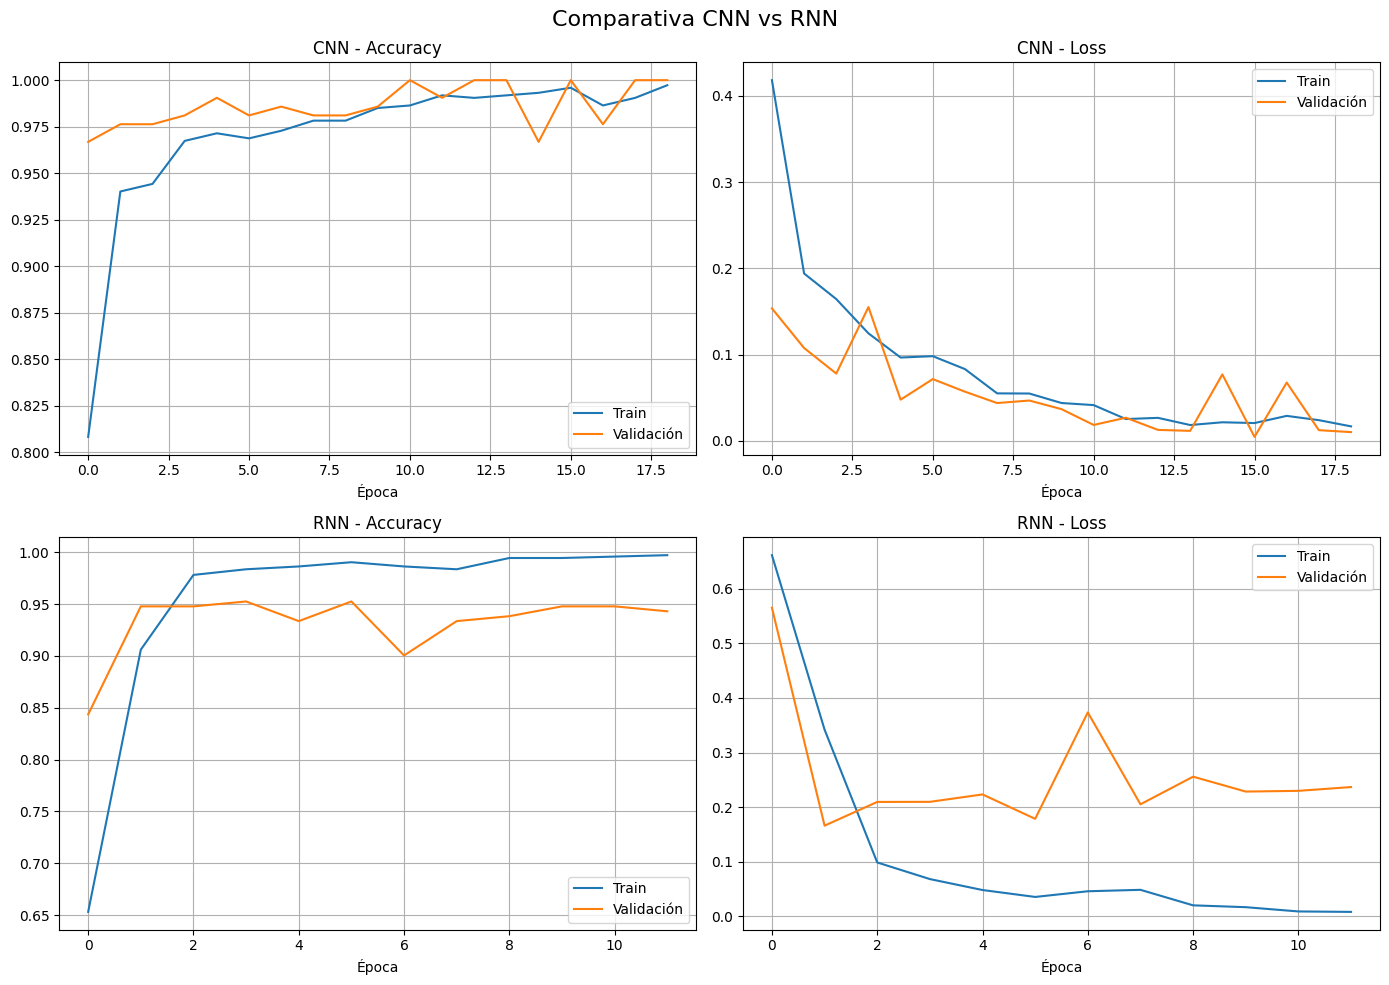

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CNN Accuracy
axes[0,0].plot(history_cnn.history['accuracy'], label='Train')
axes[0,0].plot(history_cnn.history['val_accuracy'], label='Validación')
axes[0,0].set_title('CNN - Accuracy')
axes[0,0].set_xlabel('Época')
axes[0,0].legend()
axes[0,0].grid(True)

# CNN Loss
axes[0,1].plot(history_cnn.history['loss'], label='Train')
axes[0,1].plot(history_cnn.history['val_loss'], label='Validación')
axes[0,1].set_title('CNN - Loss')
axes[0,1].set_xlabel('Época')
axes[0,1].legend()
axes[0,1].grid(True)

# RNN Accuracy
axes[1,0].plot(history_rnn.history['accuracy'], label='Train')
axes[1,0].plot(history_rnn.history['val_accuracy'], label='Validación')
axes[1,0].set_title('RNN - Accuracy')
axes[1,0].set_xlabel('Época')
axes[1,0].legend()
axes[1,0].grid(True)

# RNN Loss
axes[1,1].plot(history_rnn.history['loss'], label='Train')
axes[1,1].plot(history_rnn.history['val_loss'], label='Validación')
axes[1,1].set_title('RNN - Loss')
axes[1,1].set_xlabel('Época')
axes[1,1].legend()
axes[1,1].grid(True)

plt.suptitle('Comparativa CNN vs RNN', fontsize=16)
plt.tight_layout()
plt.show()

# subir audio

In [29]:
from IPython.display import HTML, display, Audio, clear_output
import ipywidgets as widgets
import librosa
import numpy as np
import os

base_path = '/content/AudioDataset/DvC'

clase_w = widgets.Dropdown(
    options=['Cats','Dogs'], description='Clase:',
    style={'description_width':'60px'},
    layout=widgets.Layout(width='180px')
)
archivo_w = widgets.Dropdown(
    options=sorted([f for f in os.listdir(f'{base_path}/Cats') if f.endswith('.wav')]),
    description='Audio:',
    style={'description_width':'60px'},
    layout=widgets.Layout(width='220px')
)
btn = widgets.Button(description='▶ Analizar', button_style='success',
                     layout=widgets.Layout(width='110px'))
out = widgets.Output()

def on_clase(change):
    archivo_w.options = sorted([f for f in os.listdir(f'{base_path}/{clase_w.value}') if f.endswith('.wav')])

clase_w.observe(on_clase, names='value')

def on_click(b):
    with out:
        clear_output(wait=True)
        clase  = clase_w.value
        archivo = archivo_w.value
        ruta   = f'{base_path}/{clase}/{archivo}'
        real   = "🐱 Gato" if clase == 'Cats' else "🐶 Perro"

        # Cargar audio
        y, sr = librosa.load(ruta, sr=22050, duration=3, mono=True)
        if len(y) < 22050*3:
            y = np.pad(y, (0, 22050*3 - len(y)))

        # Reproducir
        display(Audio(y, rate=sr))

        # Visualizar señal + espectrograma
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        librosa.display.waveshow(y, sr=sr, ax=axes[0], color='#1D9E75' if clase=='Cats' else '#D85A30')
        axes[0].set_title(f'Señal Temporal — {real}')
        axes[0].set_xlabel('Tiempo (s)')

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
        axes[1].set_title('Mel-Spectrogram (CNN)')
        fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
        plt.tight_layout()
        plt.show()

        # CNN
        X_cnn = mel_db[np.newaxis,...,np.newaxis].astype(np.float32)
        minv, maxv = X_cnn.min(), X_cnn.max()
        if maxv - minv > 0: X_cnn = (X_cnn - minv) / (maxv - minv)

        # RNN
        y_norm = (y - y.mean()) / (y.std() + 1e-8)
        frames = librosa.util.frame(y_norm, frame_length=512, hop_length=256).T
        X_rnn = frames[np.newaxis,...].astype(np.float32)
        X_rnn = (X_rnn - mean_t) / std_t

        pred_cnn = float(modelo_cnn.predict(X_cnn, verbose=0)[0][0])
        pred_rnn = float(modelo_rnn.predict(X_rnn, verbose=0)[0][0])

        clase_cnn = "🐶 Perro" if pred_cnn > 0.5 else "🐱 Gato"
        clase_rnn = "🐶 Perro" if pred_rnn > 0.5 else "🐱 Gato"
        ok_cnn = "✅" if clase_cnn == real else "❌"
        ok_rnn = "✅" if clase_rnn == real else "❌"
        pct_cnn = round(pred_cnn*100 if pred_cnn>0.5 else (1-pred_cnn)*100)
        pct_rnn = round(pred_rnn*100 if pred_rnn>0.5 else (1-pred_rnn)*100)

        print("─" * 40)
        print(f"  Clase real:  {real}")
        print(f"  CNN  →  {clase_cnn}  {ok_cnn}  ({pct_cnn}% confianza)")
        print(f"  RNN  →  {clase_rnn}  {ok_rnn}  ({pct_rnn}% confianza)")
        print("─" * 40)

btn.on_click(on_click)
display(widgets.HBox([clase_w, archivo_w, btn]), out)

Output()